Task 1



импорты и параметры

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

# Parameters
np.random.seed(123)
T = 200          # sample size
N = 1000         # number of simulations
alpha = 0.05     # significance level for tests

# Store results
r2_rw = []
r2_trend_rw = []
r2_wn = []
r2_trend_wn = []
granger_pvals = []

случайное блуждание

In [ ]:
for i in range(N):
    # Random walks
    e = np.random.normal(0, 1, T)
    eta = np.random.normal(0, 1, T)
    x = np.cumsum(e)
    y = np.cumsum(eta)
    time = np.arange(1, T+1)

    # Regression y ~ x
    X = np.column_stack([np.ones(T), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    y_pred = X @ b
    resid = y - y_pred
    TSS = np.sum((y - np.mean(y))**2)
    RSS = np.sum(resid**2)
    r2 = 1 - RSS/TSS
    r2_rw.append(r2)

    # Regression y ~ time
    X_t = np.column_stack([np.ones(T), time])
    b_t = np.linalg.lstsq(X_t, y, rcond=None)[0]
    y_pred_t = X_t @ b_t
    resid_t = y - y_pred_t
    TSS_t = np.sum((y - np.mean(y))**2)
    RSS_t = np.sum(resid_t**2)
    r2_t = 1 - RSS_t/TSS_t
    r2_trend_rw.append(r2_t)

# Compute proportions
prop_20 = np.mean(np.array(r2_rw) > 0.2)
prop_70 = np.mean(np.array(r2_rw) > 0.7)
print(f"Random walk regressions: proportion R² > 0.2 = {prop_20:.3f}, > 0.7 = {prop_70:.3f}")

Random walk regressions: proportion R² > 0.2 = 0.460, > 0.7 = 0.053


тренд

In [ ]:
prop_trend_20 = np.mean(np.array(r2_trend_rw) > 0.2)
prop_trend_70 = np.mean(np.array(r2_trend_rw) > 0.7)
print(f"Random walk vs. time trend: proportion R² > 0.2 = {prop_trend_20:.3f}, > 0.7 = {prop_trend_70:.3f}")

Random walk vs. time trend: proportion R² > 0.2 = 0.693, > 0.7 = 0.288


ccf

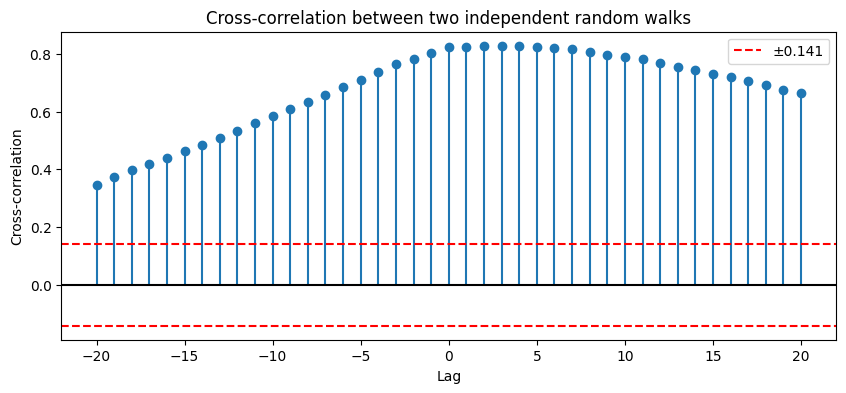

In [ ]:
# Generate one pair
e = np.random.normal(0, 1, T)
eta = np.random.normal(0, 1, T)
x = np.cumsum(e)
y = np.cumsum(eta)

# Compute cross-correlation (statsmodels ccf gives correlations for lags 0,1,... up to nlags)
# For negative lags we reverse the series.
nlags = 20
ccf_pos = ccf(y, x, adjusted=False)[:nlags+1]   # lags 0..20
ccf_neg = ccf(x, y, adjusted=False)[1:nlags+1]  # lags -1..-20
lags = np.arange(-nlags, nlags+1)
ccf_vals = np.concatenate([ccf_neg[::-1], ccf_pos])

# 95% confidence bounds ~ ±2/sqrt(T)
bound = 2/np.sqrt(T)

plt.figure(figsize=(10,4))
plt.stem(lags, ccf_vals, basefmt=" ")
plt.axhline(bound, color='r', linestyle='--', label=f'±{bound:.3f}')
plt.axhline(-bound, color='r', linestyle='--')
plt.axhline(0, color='k')
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation between two independent random walks')
plt.legend()
plt.show()

причинность

In [ ]:
granger_reject = 0
maxlags = 5   # maximum lags to consider

for i in range(N):
    e = np.random.normal(0, 1, T)
    eta = np.random.normal(0, 1, T)
    x = np.cumsum(e)
    y = np.cumsum(eta)
    data = pd.DataFrame({'x': x, 'y': y})

    # Fit VAR with automatic lag selection (AIC)
    try:
        model = VAR(data)
        lag_order = model.select_order(maxlags=maxlags)
        selected_lag = lag_order.aic  # may be None if no model fits; fallback to 1
        if selected_lag is None or selected_lag == 0:
            selected_lag = 1
    except:
        selected_lag = 1

    # Granger causality test: x does not Granger-cause y
    try:
        gc_result = grangercausalitytests(data[['y','x']], maxlag=selected_lag, verbose=False)
        pval = gc_result[selected_lag][0]['ssr_chi2test'][1]
        if pval < alpha:
            granger_reject += 1
    except:
        pass

prop_granger = granger_reject / N
print(f"Granger causality test (x→y) rejection rate at α={alpha}: {prop_granger:.3f}")

Granger causality test (x→y) rejection rate at α=0.05: 0.216


var

In [ ]:
# Generate one pair
e = np.random.normal(0, 1, T)
eta = np.random.normal(0, 1, T)
x = np.cumsum(e)
y = np.cumsum(eta)
data = pd.DataFrame({'x': x, 'y': y})

model = VAR(data)
results = model.fit(1)   # VAR(1)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 22, Mar, 2026
Time:                     22:06:14
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  -0.102854
Nobs:                     199.000    HQIC:                 -0.161962
Log likelihood:          -538.624    FPE:                   0.816976
AIC:                    -0.202150    Det(Omega_mle):        0.792890
--------------------------------------------------------------------
Results for equation x
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.136434         0.173097           -0.788           0.431
L1.x          0.988169         0.010409           94.932           0.000
L1.y         -0.018779         0.013310           -1.411           0.158

Results for equation y

белый шум

In [ ]:
for i in range(N):
    x = np.random.normal(0, 1, T)
    y = np.random.normal(0, 1, T)
    time = np.arange(1, T+1)

    # Regression y ~ x
    X = np.column_stack([np.ones(T), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    y_pred = X @ b
    resid = y - y_pred
    TSS = np.sum((y - np.mean(y))**2)
    RSS = np.sum(resid**2)
    r2 = 1 - RSS/TSS
    r2_wn.append(r2)

    # Regression y ~ time
    X_t = np.column_stack([np.ones(T), time])
    b_t = np.linalg.lstsq(X_t, y, rcond=None)[0]
    y_pred_t = X_t @ b_t
    resid_t = y - y_pred_t
    TSS_t = np.sum((y - np.mean(y))**2)
    RSS_t = np.sum(resid_t**2)
    r2_t = 1 - RSS_t/TSS_t
    r2_trend_wn.append(r2_t)

prop_20_wn = np.mean(np.array(r2_wn) > 0.2)
prop_70_wn = np.mean(np.array(r2_wn) > 0.7)
print(f"White noise regressions: proportion R² > 0.2 = {prop_20_wn:.3f}, > 0.7 = {prop_70_wn:.3f}")

prop_trend_20_wn = np.mean(np.array(r2_trend_wn) > 0.2)
prop_trend_70_wn = np.mean(np.array(r2_trend_wn) > 0.7)
print(f"White noise vs. time trend: proportion R² > 0.2 = {prop_trend_20_wn:.3f}, > 0.7 = {prop_trend_70_wn:.3f}")

White noise regressions: proportion R² > 0.2 = 0.000, > 0.7 = 0.000
White noise vs. time trend: proportion R² > 0.2 = 0.000, > 0.7 = 0.000


Task 2, депозиты

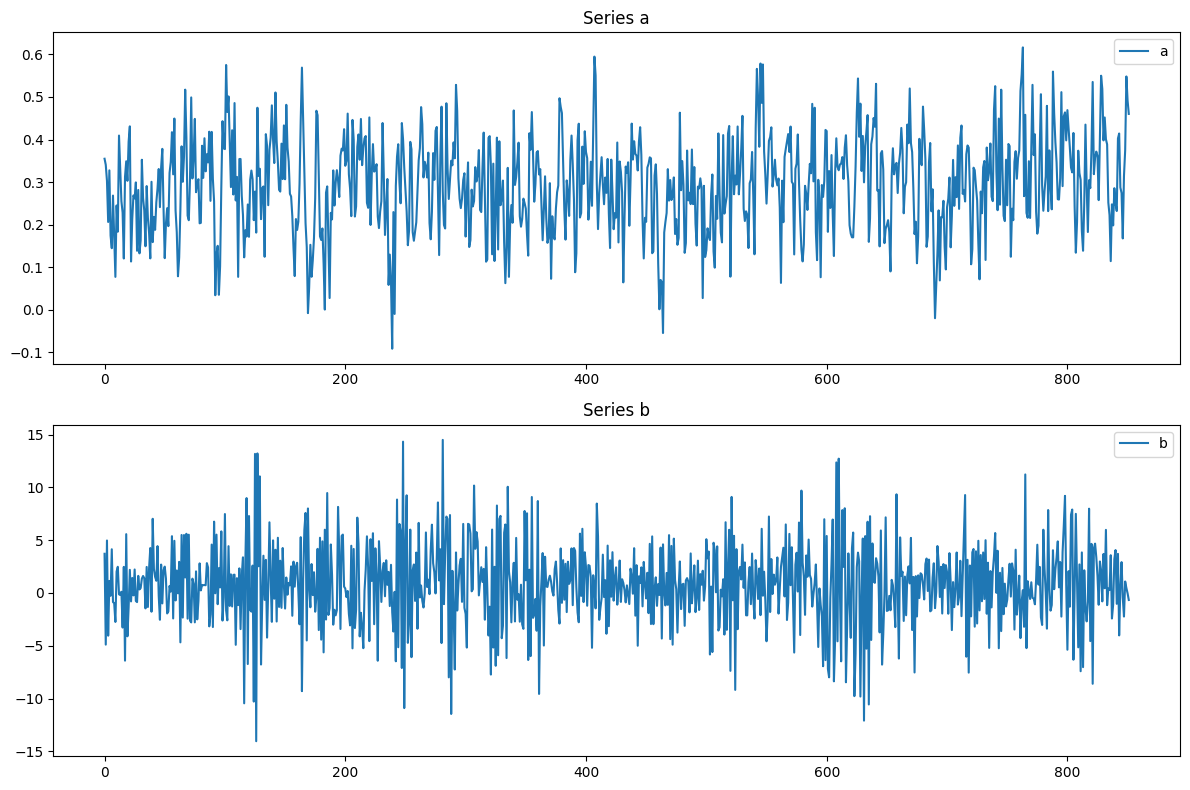

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

# Load your data (adjust path and column names)
df = pd.read_excel('/content/data (1).xlsx')
a = df['a'].dropna()
b = df['b'].dropna()

# Trim to same length
min_len = min(len(a), len(b))
a = a.iloc[:min_len]
b = b.iloc[:min_len]

# Visualize

def plot_series(series1, series2, name1='a', name2='b'):
    """Plot two series side by side."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].plot(series1, label=name1)
    axes[0].set_title(f'Series {name1}')
    axes[0].legend()
    axes[1].plot(series2, label=name2)
    axes[1].set_title(f'Series {name2}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
plot_series(a, b, 'a', 'b')

In [ ]:
def stationarity_tests(series, name="Series", alpha=0.05):
    """
    Run ADF, KPSS, and Phillips-Perron (from arch package) stationarity tests.

    Parameters
    ----------
    series : array-like
        The time series to test.
    name : str, optional
        A label for the series (used in printing).
    alpha : float, optional
        Significance level for the tests (default 0.05).

    Returns
    -------
    dict
        A dictionary containing test statistics, p-values, and stationarity flags.
    """
    # Convert to numpy array and check for missing values
    series = np.asarray(series, dtype=float)
    if np.any(np.isnan(series)):
        print("WARNING: Series contains missing values. Stationarity tests may fail or produce invalid results.")

    print(f"\n{'='*60}")
    print(f"STATIONARITY ANALYSIS: {name}")
    print(f"{'='*60}")

    # 1. ADF Test
    print("\n1. AUGMENTED DICKEY-FULLER (ADF) TEST:")
    adf_result = adfuller(series, autolag='AIC')
    print(f"   Test Statistic: {adf_result[0]:.4f}")
    print(f"   p-value: {adf_result[1]:.4f}")
    print(f"   Lags used: {adf_result[2]}")
    print(f"   Critical Values:")
    for key, val in adf_result[4].items():
        print(f"     {key}: {val:.4f}")

    # 2. KPSS Test
    print("\n2. KPSS TEST:")
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f"   Test Statistic: {kpss_result[0]:.4f}")
    print(f"   p-value: {kpss_result[1]:.4f}")

    # 3. Phillips-Perron Test using arch package (explicitly required)
    print("\n3. PHILLIPS-PERRON (PP) TEST (from arch):")
    try:
        from arch.unitroot import PhillipsPerron
        pp = PhillipsPerron(series, trend='c', lags=None)  # automatic lag selection
        pp_stat = pp.stat
        pp_pvalue = pp.pvalue
        print(f"   Test Statistic: {pp_stat:.4f}")
        print(f"   p-value: {pp_pvalue:.4f}")
        print(f"   Lags used: {pp.lags}")  # corrected attribute
    except ImportError:
        raise ImportError(
            "The arch package is required for the Phillips-Perron test. "
            "Please install it using: pip install arch"
        )

    # Determine stationarity
    adf_stationary = adf_result[1] <= alpha
    kpss_stationary = kpss_result[1] >= alpha
    pp_stationary = pp_pvalue <= alpha

    print(f"\nCONCLUSION (at α={alpha}):")
    print(f"   ADF  : {'Stationary' if adf_stationary else 'Non-stationary'}")
    print(f"   PP   : {'Stationary' if pp_stationary else 'Non-stationary'}")
    print(f"   KPSS : {'Stationary' if kpss_stationary else 'Non-stationary'}")

    # Combined verdict (simple majority)
    stationary_count = sum([adf_stationary, kpss_stationary, pp_stationary])
    if stationary_count >= 2:
        print(f"   OVERALL: Likely STATIONARY (based on {stationary_count}/3 tests)")
    else:
        print(f"   OVERALL: Likely NON-STATIONARY (based on {stationary_count}/3 tests)")

    return {
        'adf_stat': adf_result[0],
        'adf_pvalue': adf_result[1],
        'adf_stationary': adf_stationary,
        'kpss_stat': kpss_result[0],
        'kpss_pvalue': kpss_result[1],
        'kpss_stationary': kpss_stationary,
        'pp_stat': pp_stat,
        'pp_pvalue': pp_pvalue,
        'pp_stationary': pp_stationary,
        'alpha': alpha
    }



def eacf(series, ar_max=7, ma_max=7):
    """Compute EACF table (R required) or fallback to ACF/PACF."""
    if R_AVAILABLE:
        y_r = robjects.FloatVector(series)
        eacf_res = TSA.eacf(y_r, ar_max=ar_max, ma_max=ma_max)
        eacf_mat = np.array(eacf_res.rx2('eacf'))
        print("EACF table (rows = AR order, cols = MA order):")
        print(eacf_mat)
        # Visual interpretation: look for a corner of zeros
    else:
        print("EACF not available; using ACF/PACF plots.")
        fig, ax = plt.subplots(2, 1, figsize=(12, 6))
        plot_acf(series, ax=ax[0])
        plot_pacf(series, ax=ax[1])
        plt.show()


def granger_test(data, var, cause, maxlag=10):
    """Return best lag and p-value for causality cause -> var."""
    from statsmodels.tsa.stattools import grangercausalitytests
    res = grangercausalitytests(data[[var, cause]], maxlag=maxlag, verbose=False)
    best_p = 1.0
    best_lag = 1
    for lag in range(1, maxlag+1):
        p_val = res[lag][0]['ssr_ftest'][1]
        if p_val < best_p:
            best_p = p_val
            best_lag = lag
    return best_lag, best_p


def arch_test(residuals, lags=10):
    """Test for ARCH effects using LM test."""
    from statsmodels.stats.diagnostic import het_arch
    lm = het_arch(residuals, nlags=lags)
    print(f"ARCH LM test: LM = {lm[0]:.4f}, p-value = {lm[1]:.4f}")
    if lm[1] < 0.05:
        print("Reject H0 → ARCH effects present.")
        return True
    else:
        print("Cannot reject H0 → no ARCH effects.")
        return False


def plot_series(series1, series2, name1='a', name2='b'):
    """Plot two series side by side."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].plot(series1, label=name1)
    axes[0].set_title(f'Series {name1}')
    axes[0].legend()
    axes[1].plot(series2, label=name2)
    axes[1].set_title(f'Series {name2}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.6 MB/s eta 0:00:00


In [ ]:
# Test original series
stationarity_tests(a, 'a')
stationarity_tests(b, 'b')

# If needed, test first differences
da = a.diff().dropna()
db = b.diff().dropna()
stationarity_tests(da, 'd_a')
stationarity_tests(db, 'd_b')


STATIONARITY ANALYSIS: a

1. AUGMENTED DICKEY-FULLER (ADF) TEST:
   Test Statistic: -17.9774
   p-value: 0.0000
   Lags used: 0
   Critical Values:
     1%: -3.4381
     5%: -2.8649
     10%: -2.5686

2. KPSS TEST:
   Test Statistic: 0.4791
   p-value: 0.0464

3. PHILLIPS-PERRON (PP) TEST (from arch):
   Test Statistic: -18.7059
   p-value: 0.0000
   Lags used: 21

CONCLUSION (at α=0.05):
   ADF  : Stationary
   PP   : Stationary
   KPSS : Non-stationary
   OVERALL: Likely STATIONARY (based on 2/3 tests)

STATIONARITY ANALYSIS: b

1. AUGMENTED DICKEY-FULLER (ADF) TEST:
   Test Statistic: -44.2020
   p-value: 0.0000
   Lags used: 0
   Critical Values:
     1%: -3.4381
     5%: -2.8649
     10%: -2.5686

2. KPSS TEST:
   Test Statistic: 0.1325
   p-value: 0.1000

3. PHILLIPS-PERRON (PP) TEST (from arch):
   Test Statistic: -44.3835
   p-value: 0.0000
   Lags used: 21

CONCLUSION (at α=0.05):
   ADF  : Stationary
   PP   : Stationary
   KPSS : Stationary
   OVERALL: Likely STATIONARY (ba

{'adf_stat': np.float64(-10.660712894673189),
 'adf_pvalue': np.float64(4.414676990313466e-19),
 'adf_stationary': np.True_,
 'kpss_stat': np.float64(0.0453117085702265),
 'kpss_pvalue': np.float64(0.1),
 'kpss_stationary': np.True_,
 'pp_stat': np.float64(-245.87357321181238),
 'pp_pvalue': 0.0,
 'pp_stationary': True,
 'alpha': 0.05}

            RUB_short  RUB_medium  RUB_long
date                                       
2014-01-01       5.30        7.32      7.43
2014-02-01       5.09        7.30      7.28
2014-03-01       5.07        7.17      7.08
2014-04-01       5.18        7.61      6.97
2014-05-01       5.19        7.85      6.95


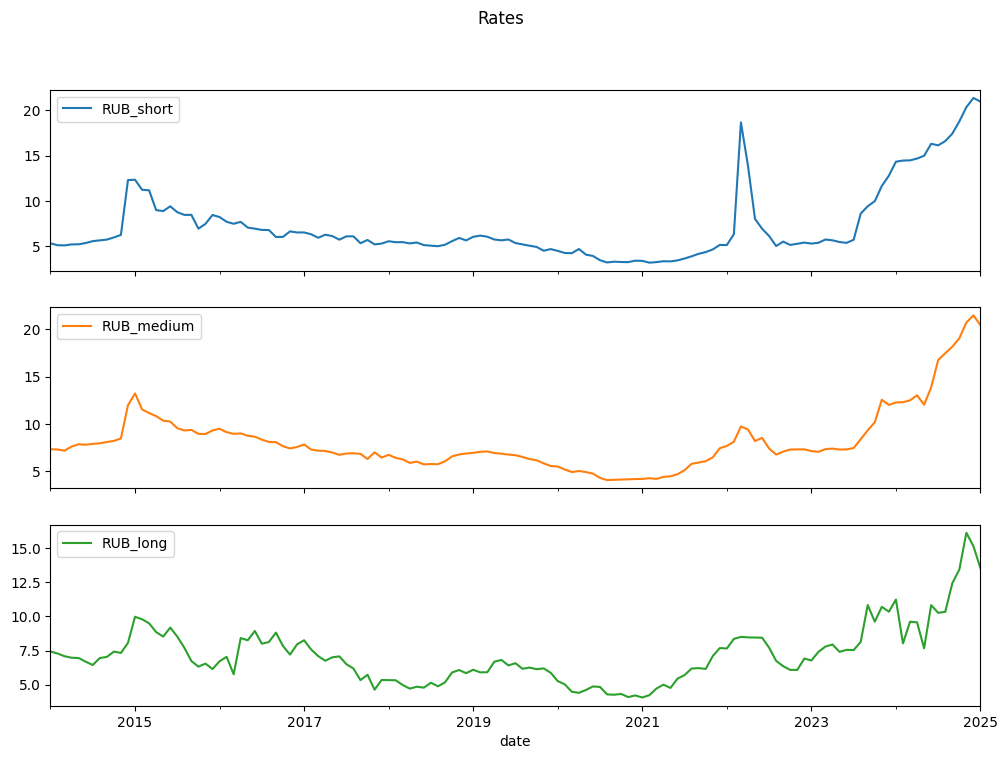

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

# Mapping of Russian month names to month numbers
month_map = {
    'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4, 'Май': 5, 'Июнь': 6,
    'Июль': 7, 'Август': 8, 'Сентябрь': 9, 'Октябрь': 10, 'Ноябрь': 11, 'Декабрь': 12
}

def parse_russian_date(date_str):
    """Parse a string like 'Январь 2014' into a datetime object."""
    month_str, year_str = date_str.split()
    month = month_map[month_str]
    year = int(year_str)
    return datetime(year, month, 1)

# Load the RUB sheet
file_path = 'deposits.xlsx'
df_rub = pd.read_excel(file_path, sheet_name='ставки_руб', header=4, skipfooter=1)

# Select the three maturity columns:
# Column H (index 7) - "до 1 года, включая ''до востребова-ния''"
# Column J (index 9) - "от 1 года до 3 лет"
# Column K (index 10) - "свыше 3 лет"
rates = df_rub.iloc[:, [0, 7, 9, 10]].copy()
rates.columns = ['date', 'RUB_short', 'RUB_medium', 'RUB_long']

# Convert date column
rates['date'] = rates['date'].apply(parse_russian_date)

# Convert rates to numeric (coerce errors, e.g., '-' or empty cells)
for col in ['RUB_short', 'RUB_medium', 'RUB_long']:
    rates[col] = pd.to_numeric(rates[col], errors='coerce')

# Drop rows with any missing values
rates.dropna(inplace=True)

# Set date as index and sort
rates.set_index('date', inplace=True)
rates.sort_index(inplace=True)

# Display first few rows
print(rates.head())

rates.plot(subplots=True, figsize=(12, 8))
plt.suptitle("Rates")
plt.show()

# Optionally save to CSV
# rates.to_csv('rub_term_structure.csv')

СТационарность

In [ ]:
def adf_test(series, title):
    print(f'ADF test for {title}:')
    for reg in ['c', 'ct']:
        result = adfuller(series, regression=reg, autolag='AIC')
        print(f'  {reg}: statistic = {result[0]:.4f}, p-value = {result[1]:.4f}')
    print()

def kpss_test(series, title):
    print(f'KPSS test for {title}:')
    for reg in ['c', 'ct']:
        stat, p_value, lags, crit = kpss(series, regression=reg, nlags='auto')
        print(f'  {reg}: statistic = {stat:.4f}, p-value = {p_value:.4f}')
    print()

for col in rates.columns:
    adf_test(rates[col], col)
    kpss_test(rates[col], col)

ADF test for RUB_short:
  c: statistic = -0.0820, p-value = 0.9512
  ct: statistic = -0.5112, p-value = 0.9830

KPSS test for RUB_short:
  c: statistic = 0.4998, p-value = 0.0417
  ct: statistic = 0.3296, p-value = 0.0100

ADF test for RUB_medium:
  c: statistic = 0.2343, p-value = 0.9741
  ct: statistic = 1.1947, p-value = 1.0000

KPSS test for RUB_medium:
  c: statistic = 0.4448, p-value = 0.0578
  ct: statistic = 0.3658, p-value = 0.0100

ADF test for RUB_long:
  c: statistic = -0.4752, p-value = 0.8968
  ct: statistic = -0.8682, p-value = 0.9594

KPSS test for RUB_long:
  c: statistic = 0.4962, p-value = 0.0425
  ct: statistic = 0.3790, p-value = 0.0100



Коинтеграция

In [ ]:
from statsmodels.tsa.stattools import coint

print("Engle‑Granger tests for all three variables (RUB_short, RUB_medium, RUB_long):")
# Different choices of dependent variable
for dep in rates.columns:
    others = [c for c in rates.columns if c != dep]
    # coint function requires y and x (can be multiple x)
    result = coint(rates[dep], rates[others], trend='c')  # constant in cointegrating relation
    print(f" Dependent: {dep}, test statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")

Engle‑Granger tests for all three variables (RUB_short, RUB_medium, RUB_long):
 Dependent: RUB_short, test statistic = -6.3842, p-value = 0.0000
 Dependent: RUB_medium, test statistic = -5.5008, p-value = 0.0001
 Dependent: RUB_long, test statistic = -4.0370, p-value = 0.0221


In [ ]:
pairs = [('RUB_short','RUB_medium'), ('RUB_short','RUB_long'), ('RUB_long','RUB_medium')]
print("\nPairwise Engle‑Granger tests:")
for (y, x) in pairs:
    result = coint(rates[y], rates[x], trend='c')
    print(f" ({y}, {x}): statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")


Pairwise Engle‑Granger tests:
 (RUB_short, RUB_medium): statistic = -6.3868, p-value = 0.0000
 (RUB_short, RUB_long): statistic = -5.4211, p-value = 0.0000
 (RUB_long, RUB_medium): statistic = -4.0417, p-value = 0.0063


Var

In [ ]:
# Convert to numpy array
data = rates.values
model = VAR(data)
lag_order = select_order(data, maxlags=8, deterministic='co')  # 'co' = constant outside cointegration
print(lag_order.summary())

 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -1.107    -0.7657*      0.3306    -0.9683*
1     -1.122*     -0.5761     0.3258*     -0.9003
2      -1.120     -0.3695      0.3267     -0.8151
3      -1.099     -0.1434      0.3343     -0.7106
4      -1.109     0.05107      0.3317     -0.6377
5      -1.035      0.3294      0.3582     -0.4809
6     -0.9862      0.5831      0.3779     -0.3487
7     -0.9187      0.8554      0.4067     -0.1980
8     -0.8721       1.107      0.4293    -0.06829
-------------------------------------------------


In [ ]:
# Johansen test with constant in cointegrating relation (det_order=1)
jres = coint_johansen(data, det_order=1, k_ar_diff=1)
print("Trace statistic:")
print(jres.lr1)
print("Critical values (90%, 95%, 99%):")
print(jres.cvt)
print("\nMax eigenvalue statistic:")
print(jres.lr2)
print("Critical values:")
print(jres.cvm)

Trace statistic:
[6.24702108e+01 1.73701493e+01 1.47345518e-02]
Critical values (90%, 95%, 99%):
[[32.0645 35.0116 41.0815]
 [16.1619 18.3985 23.1485]
 [ 2.7055  3.8415  6.6349]]

Max eigenvalue statistic:
[4.51000615e+01 1.73554147e+01 1.47345518e-02]
Critical values:
[[21.8731 24.2522 29.2631]
 [15.0006 17.1481 21.7465]
 [ 2.7055  3.8415  6.6349]]


VECM

In [ ]:
# Estimate VECM with r cointegrating relations, deterministic term 'co' (constant outside cointegration)
vecm_model = VECM(data, k_ar_diff=1, coint_rank=1, deterministic='co')
vecm_res = vecm_model.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation y1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9776      0.228     -4.296      0.000      -1.424      -0.532
L1.y1          0.2275      0.107      2.119      0.034       0.017       0.438
L1.y2         -0.0334      0.237     -0.141      0.888      -0.498       0.431
L1.y3          0.0297      0.158      0.189      0.850      -0.279       0.338
Det. terms outside the coint. relation & lagged endog. parameters for equation y2
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0069      0.108      0.064      0.949      -0.204       0.218
L1.y1          0.0559      0.051      1.098      0.272      -0.044       0.156
L1.y2          0.1714      0.112      1.528   

диагностика

In [ ]:
resid = vecm_res.resid

# Ljung‑Box test for autocorrelation (lag 10)
from statsmodels.stats.diagnostic import acorr_ljungbox
for i, col in enumerate(['RUB_short', 'RUB_medium', 'RUB_long']):
    lb_result = acorr_ljungbox(resid[:, i], lags=[10], return_df=True)
    # In some versions, the column is 'lb_pvalue', in others 'pvalue'
    if 'lb_pvalue' in lb_result.columns:
        pval = lb_result['lb_pvalue'].iloc[0]
    else:
        pval = lb_result['pvalue'].iloc[0]
    print(f'{col}: Ljung‑Box p-value (lag 10) = {pval:.4f}')

# ARCH test
from statsmodels.stats.diagnostic import het_arch
for i, col in enumerate(['RUB_short', 'RUB_medium', 'RUB_long']):
    arch_stat, p_value, _, _ = het_arch(resid[:, i])
    print(f'{col}: ARCH test p-value = {p_value:.4f}')

# Multivariate normality
import pingouin as pg
norm_test = pg.multivariate_normality(resid)
print(norm_test)

RUB_short: Ljung‑Box p-value (lag 10) = 0.6937
RUB_medium: Ljung‑Box p-value (lag 10) = 0.0849
RUB_long: Ljung‑Box p-value (lag 10) = 0.6179
RUB_short: ARCH test p-value = 1.0000
RUB_medium: ARCH test p-value = 0.0003
RUB_long: ARCH test p-value = 0.0000
HZResults(hz=np.float64(11.45592533389602), pval=np.float64(2.663427329146125e-46), normal=False)


Прогнозы

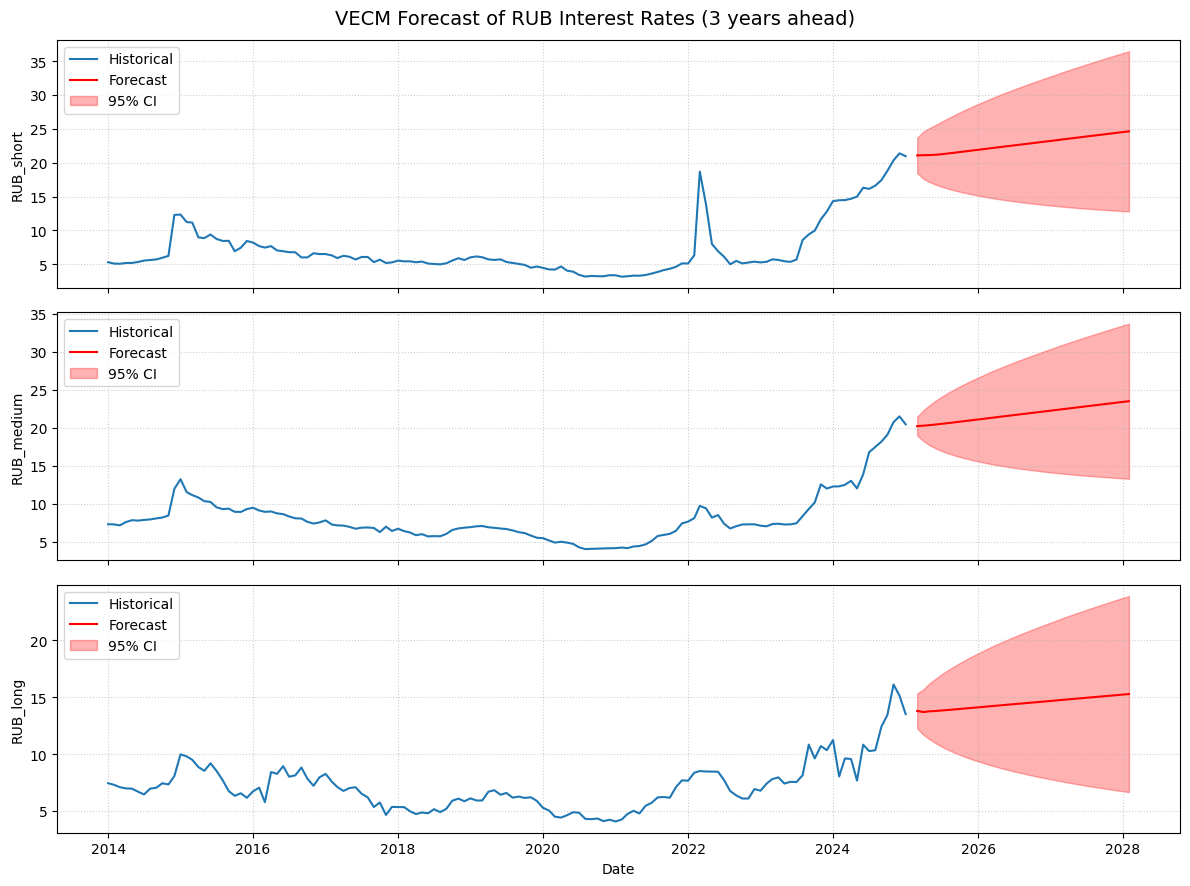

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming rub_series is your historical DataFrame with columns ['RUB_short', 'RUB_medium', 'RUB_long']
# and vecm_res is your fitted VECMResults object.

# Generate forecasts
forecast, lower, upper = vecm_res.predict(steps=36, alpha=0.05)

# Create forecast index (monthly, starting after last historical date)
last_date = rates.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=36, freq='M')

# Convert to DataFrames for convenience
forecast_df = pd.DataFrame(forecast, columns=rates.columns, index=forecast_index)
lower_df = pd.DataFrame(lower, columns=rates.columns, index=forecast_index)
upper_df = pd.DataFrame(upper, columns=rates.columns, index=forecast_index)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for i, col in enumerate(rates.columns):
    axes[i].plot(rates.index, rates[col], label='Historical', linewidth=1.5)
    axes[i].plot(forecast_df.index, forecast_df[col], label='Forecast', color='red', linewidth=1.5)
    axes[i].fill_between(forecast_df.index, lower_df[col], upper_df[col], alpha=0.3, color='red', label='95% CI')
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, linestyle=':', alpha=0.6)
axes[-1].set_xlabel('Date')
plt.suptitle('VECM Forecast of RUB Interest Rates (3 years ahead)', fontsize=14)
plt.tight_layout()
plt.show()

irf

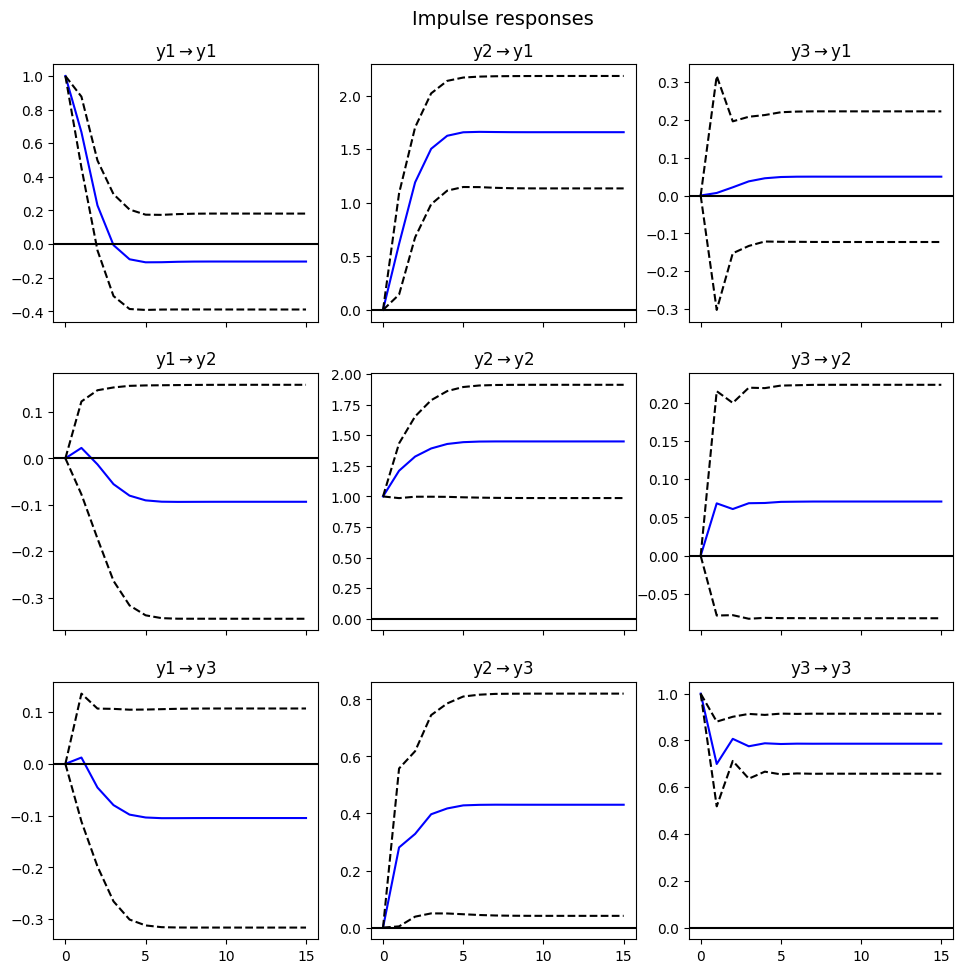

In [ ]:
from statsmodels.tsa.vector_ar import irf
irf = vecm_res.irf(15)
irf.plot(orth = False)
plt.show()

NameError: name 'fevd_array' is not defined

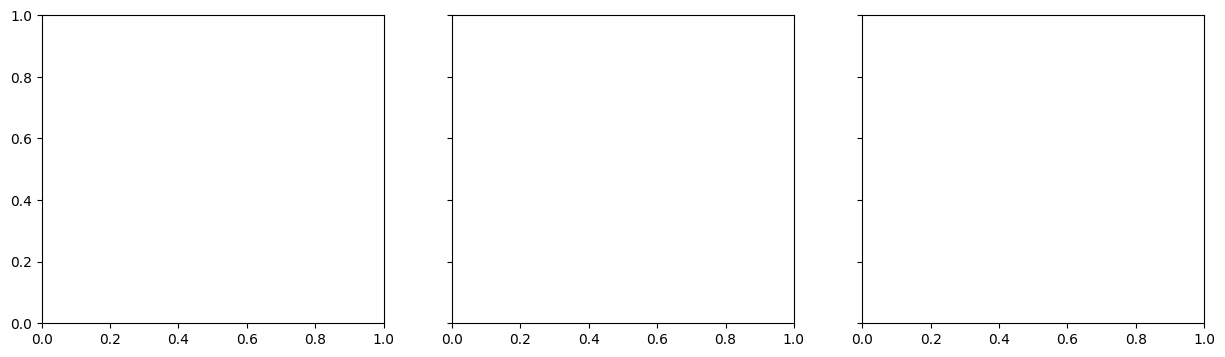

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Use your fevd array (replace with your actual variable)
# Example: fevd_array = np.array(fevd_list)  # shape (periods, 3, 3)
# If you haven't computed it, run the earlier manual FEVD code.
# ------------------------------------------------------------

# Select horizons to display (0‑based indices)
horizon_indices = [0, 11, 23, 47, 95]   # corresponds to months 1,12,24,48,96
horizon_labels = ['1', '12', '24', '48', '96']

var_names = ['Short rate', 'Medium rate', 'Long rate']
shock_names = ['Shock to short', 'Shock to medium', 'Shock to long']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # blue, orange, green

# Create one subplot per variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for var_idx in range(3):
    ax = axes[var_idx]
    # Extract data for this variable at the selected horizons
    data = fevd_array[horizon_indices, var_idx, :]   # shape (len(horizons), 3)

    # Stack bars
    bottom = np.zeros(len(horizon_indices))
    for shock_idx in range(3):
        ax.bar(horizon_labels, data[:, shock_idx], bottom=bottom,
               label=shock_names[shock_idx] if var_idx == 0 else "",
               color=colors[shock_idx])
        bottom += data[:, shock_idx]

    ax.set_title(var_names[var_idx])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Proportion')
    ax.set_xlabel('Horizon (months)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.suptitle('Forecast Error Variance Decomposition', fontsize=14)
plt.tight_layout()
plt.show()

Task 3

In [ ]:
df = pd.read_excel('/content/цены мясопродуктов.xls')
df.head()

,Куры Мск,Куры СПб,Куры свердлоская область
0,69.46,56.62,58.47
1,69.59,55.62,58.52
2,69.67,56.13,58.46
3,69.79,57.46,58.55
4,69.84,58.00,58.98


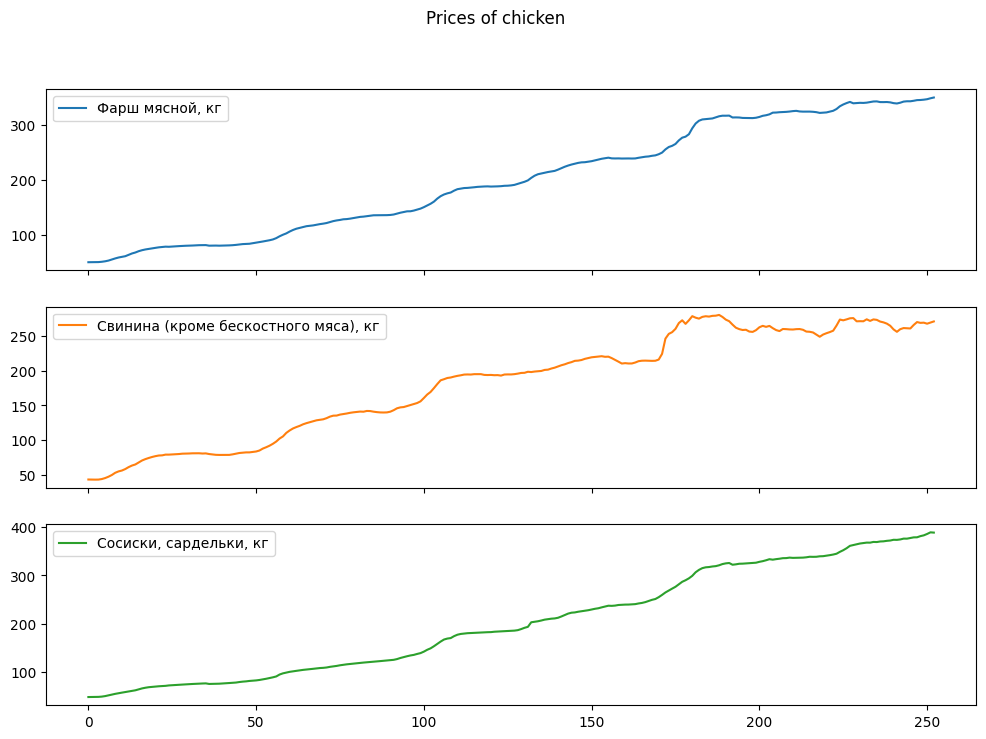

In [ ]:
df.plot(subplots=True, figsize=(12, 8))
plt.suptitle("Prices of chicken")
plt.show()


In [ ]:
def adf_test(series, title):
    print(f'ADF test for {title}:')
    for reg in ['c', 'ct']:
        result = adfuller(series, regression=reg, autolag='AIC')
        print(f'  {reg}: statistic = {result[0]:.4f}, p-value = {result[1]:.4f}')
    print()

def kpss_test(series, title):
    print(f'KPSS test for {title}:')
    for reg in ['c', 'ct']:
        stat, p_value, lags, crit = kpss(series, regression=reg, nlags='auto')
        print(f'  {reg}: statistic = {stat:.4f}, p-value = {p_value:.4f}')
    print()

for col in df.columns:
    adf_test(df[col], col)
    kpss_test(df[col], col)

ADF test for Куры Мск:
  c: statistic = -0.5017, p-value = 0.8917
  ct: statistic = -4.4045, p-value = 0.0022

KPSS test for Куры Мск:
  c: statistic = 2.2372, p-value = 0.0100
  ct: statistic = 0.1202, p-value = 0.0978

ADF test for Куры СПб:
  c: statistic = -1.0040, p-value = 0.7518
  ct: statistic = -5.2603, p-value = 0.0001

KPSS test for Куры СПб:
  c: statistic = 2.1784, p-value = 0.0100
  ct: statistic = 0.0472, p-value = 0.1000

ADF test for Куры свердлоская область:
  c: statistic = -1.6921, p-value = 0.4352
  ct: statistic = -4.0216, p-value = 0.0082

KPSS test for Куры свердлоская область:
  c: statistic = 2.1290, p-value = 0.0100
  ct: statistic = 0.0963, p-value = 0.1000



In [ ]:
from statsmodels.tsa.stattools import coint

print("Engle‑Granger tests for all three variables (Куры Москва, СПб, Свердловская область):")
# Different choices of dependent variable
for dep in df.columns:
    others = [c for c in df.columns if c != dep]
    # coint function requires y and x (can be multiple x)
    result = coint(df[dep], df[others], trend='ct')  # constant in cointegrating relation
    print(f" Dependent: {dep}, test statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")

Engle‑Granger tests for all three variables (Куры Москва, СПб, Свердловская область):
 Dependent: Куры Мск, test statistic = -4.2765, p-value = 0.0326
 Dependent: Куры СПб, test statistic = -4.2567, p-value = 0.0345
 Dependent: Куры свердлоская область, test statistic = -3.4848, p-value = 0.2052


In [ ]:
from statsmodels.tsa.stattools import coint

pairs = [('Куры Мск', 'Куры СПб'),
         ('Куры Мск', 'Куры свердлоская область'),
         ('Куры СПб', 'Куры свердлоская область')]

print("Pairwise Engle‑Granger tests:")
for (y, x) in pairs:
    result = coint(df[y], df[x], trend='c')
    print(f" ({y}, {x}): statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")

Pairwise Engle‑Granger tests:
 (Куры Мск, Куры СПб): statistic = -4.5936, p-value = 0.0009
 (Куры Мск, Куры свердлоская область): statistic = -3.5091, p-value = 0.0316
 (Куры СПб, Куры свердлоская область): statistic = -3.0097, p-value = 0.1079


In [ ]:
# Convert to numpy array
data = df.values
model = VAR(data)
lag_order = select_order(data, maxlags=8, deterministic='co')  # 'co' = constant outside cointegration
print(lag_order.summary())

 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       3.601       3.842       36.65       3.699
1      3.032*      3.417*      20.75*      3.188*
2       3.042       3.572       20.96       3.257
3       3.097       3.771       22.15       3.370
4       3.152       3.970       23.40       3.483
5       3.136       4.099       23.05       3.525
6       3.070       4.177       21.61       3.518
7       3.106       4.357       22.42       3.612
8       3.172       4.568       23.98       3.736
-------------------------------------------------


In [ ]:
# Johansen test with constant in cointegrating relation (det_order=1)
jres = coint_johansen(data, det_order=1, k_ar_diff=1)
print("Trace statistic:")
print(jres.lr1)
print("Critical values (90%, 95%, 99%):")
print(jres.cvt)
print("\nMax eigenvalue statistic:")
print(jres.lr2)
print("Critical values:")
print(jres.cvm)

Trace statistic:
[61.2998862  27.84887562 12.78782599]
Critical values (90%, 95%, 99%):
[[32.0645 35.0116 41.0815]
 [16.1619 18.3985 23.1485]
 [ 2.7055  3.8415  6.6349]]

Max eigenvalue statistic:
[33.45101058 15.06104963 12.78782599]
Critical values:
[[21.8731 24.2522 29.2631]
 [15.0006 17.1481 21.7465]
 [ 2.7055  3.8415  6.6349]]


In [ ]:
# Estimate VECM with r cointegrating relations, deterministic term 'co' (constant outside cointegration)
vecm_model = VECM(data, k_ar_diff=1, coint_rank=1, deterministic='cilt')
vecm_res = vecm_model.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation y1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1          0.3759      0.069      5.431      0.000       0.240       0.511
L1.y2          0.1016      0.035      2.914      0.004       0.033       0.170
L1.y3          0.0689      0.035      1.978      0.048       0.001       0.137
Det. terms outside the coint. relation & lagged endog. parameters for equation y2
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1          0.0142      0.150      0.095      0.925      -0.279       0.308
L1.y2          0.4544      0.075      6.021      0.000       0.307       0.602
L1.y3          0.1923      0.075      2.553      0.011       0.045       0.340
Det. terms outside the coint. relation & lagge

In [ ]:
resid = vecm_res.resid

# Ljung‑Box test for autocorrelation (lag 10)
from statsmodels.stats.diagnostic import acorr_ljungbox
for i, col in enumerate(['Куры Мск', 'Куры СПб', 'Куры свердловская область']):
    lb_result = acorr_ljungbox(resid[:, i], lags=[10], return_df=True)
    # In some versions, the column is 'lb_pvalue', in others 'pvalue'
    if 'lb_pvalue' in lb_result.columns:
        pval = lb_result['lb_pvalue'].iloc[0]
    else:
        pval = lb_result['pvalue'].iloc[0]
    print(f'{col}: Ljung‑Box p-value (lag 10) = {pval:.4f}')

# ARCH test
from statsmodels.stats.diagnostic import het_arch
for i, col in enumerate(['Куры Мск', 'Куры СПб', 'Куры свердловская область']):
    arch_stat, p_value, _, _ = het_arch(resid[:, i])
    print(f'{col}: ARCH test p-value = {p_value:.4f}')

# Multivariate normality
import pingouin as pg
norm_test = pg.multivariate_normality(resid)
print(norm_test)

Куры Мск: Ljung‑Box p-value (lag 10) = 0.6277
Куры СПб: Ljung‑Box p-value (lag 10) = 0.5711
Куры свердловская область: Ljung‑Box p-value (lag 10) = 0.2074
Куры Мск: ARCH test p-value = 0.0690
Куры СПб: ARCH test p-value = 0.0924
Куры свердловская область: ARCH test p-value = 0.1295
HZResults(hz=np.float64(5.412471940864192), pval=np.float64(1.4164297723642066e-27), normal=False)


Index already correct.


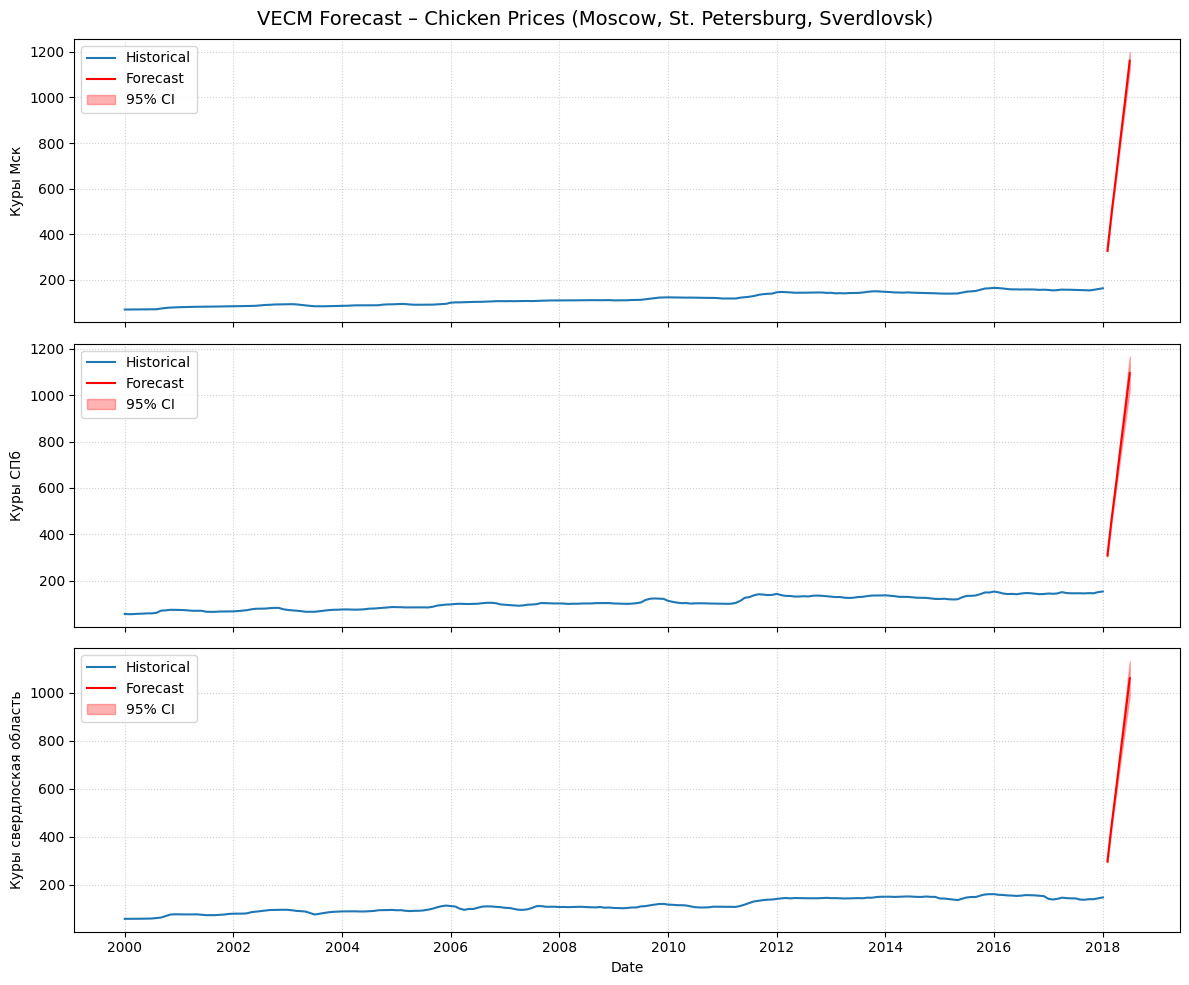

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.tseries.offsets import MonthBegin

# -------------------------------------------------------------------
# 1. Fix the index of the historical DataFrame
# -------------------------------------------------------------------
# If the index is not a proper monthly datetime, replace it with a correct range
if not isinstance(df.index, pd.DatetimeIndex) or df.index[0].year < 1990:
    # The data is in order; create a proper monthly index starting from 2000-01
    correct_index = pd.date_range(start='2000-01-01', periods=len(df), freq='MS')
    df.index = correct_index
    print("Index replaced with proper monthly dates (2000-01 to 2025-01).")
else:
    print("Index already correct.")

# -------------------------------------------------------------------
# 2. Generate forecasts from the fitted VECM
# -------------------------------------------------------------------
steps = 6
# Predict differences with 95% confidence intervals
forecast, lower, upper = vecm_res.predict(steps=steps, alpha=0.05)

# Last observed levels (latest month)
last_levels = df.iloc[-1].values

# Reconstruct levels from forecasted differences
forecast_levels = np.zeros((steps, len(df.columns)))
for t in range(steps):
    if t == 0:
        forecast_levels[t, :] = last_levels + forecast[t, :]
    else:
        forecast_levels[t, :] = forecast_levels[t-1, :] + forecast[t, :]

# Reconstruct confidence intervals for levels
lower_levels = np.zeros((steps, len(df.columns)))
upper_levels = np.zeros((steps, len(df.columns)))
for t in range(steps):
    if t == 0:
        lower_levels[t, :] = last_levels + lower[t, :]
        upper_levels[t, :] = last_levels + upper[t, :]
    else:
        lower_levels[t, :] = lower_levels[t-1, :] + lower[t, :]
        upper_levels[t, :] = upper_levels[t-1, :] + upper[t, :]

# Create date index for forecast (starting after last historical date)
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + MonthBegin(1), periods=steps, freq='MS')

# Create DataFrames for plotting
forecast_df = pd.DataFrame(forecast_levels, columns=df.columns, index=forecast_index)
lower_df   = pd.DataFrame(lower_levels, columns=df.columns, index=forecast_index)
upper_df   = pd.DataFrame(upper_levels, columns=df.columns, index=forecast_index)

# -------------------------------------------------------------------
# 3. Plot historical and forecast
# -------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], label='Historical', linewidth=1.5)
    axes[i].plot(forecast_df.index, forecast_df[col], label='Forecast', color='red', linewidth=1.5)
    axes[i].fill_between(forecast_df.index, lower_df[col], upper_df[col],
                         alpha=0.3, color='red', label='95% CI')
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, linestyle=':', alpha=0.6)

axes[-1].set_xlabel('Date')
plt.suptitle('VECM Forecast – Chicken Prices (Moscow, St. Petersburg, Sverdlovsk)', fontsize=14)
plt.tight_layout()
plt.show()

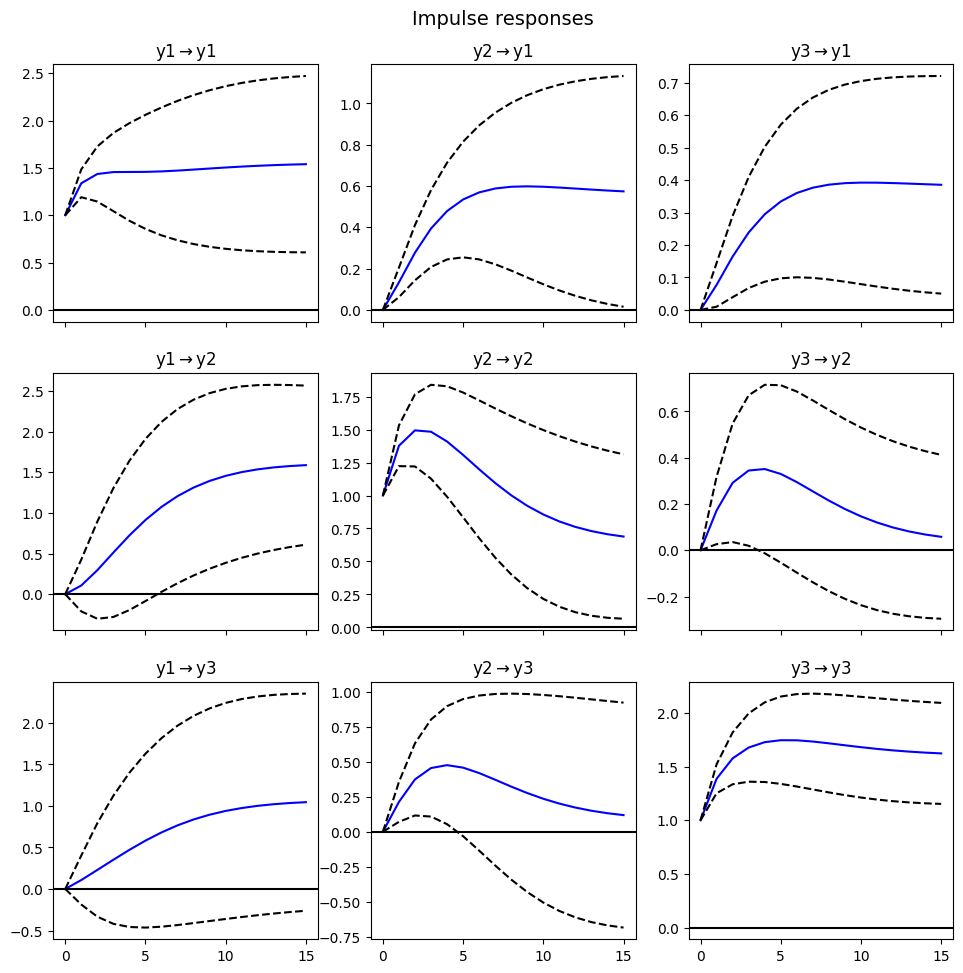

In [ ]:
from statsmodels.tsa.vector_ar import irf
irf = vecm_res.irf(15)
irf.plot(orth = False)
plt.show()

Номер 2

In [ ]:
dataset = pd.read_excel('/content/GDP per capita from 1800 (1).xlsx')
dataset.head()

,Unnamed: 0,Denmark,France,Italy,Netherlands,Sweden,England,Australia,USA,Indonesia,South Africa,World
0,1800,2099.039922,1539.441130,2658.323460,4896.906188,1478.676745,3213.171277,319.718905,2089.302517,875.994883,2317.026061,795.648142
1,1801,2111.095405,1557.206304,2624.351275,4810.178997,1466.321180,3220.231059,335.698701,2127.470872,878.302257,2291.730788,796.682919
2,1802,2123.220126,1575.176488,2709.281737,5075.705788,1534.126342,3230.215851,352.477180,2162.320238,880.615709,2266.435516,808.934775
3,1803,2135.414484,1593.354049,2785.719153,4965.906256,1518.975441,3125.861083,370.094260,2125.811378,882.935254,2241.140243,805.680142
4,1804,2147.678878,1611.741379,2904.621800,5202.204042,1419.992754,3079.954902,388.591856,2124.151884,885.260909,2215.844970,812.788717


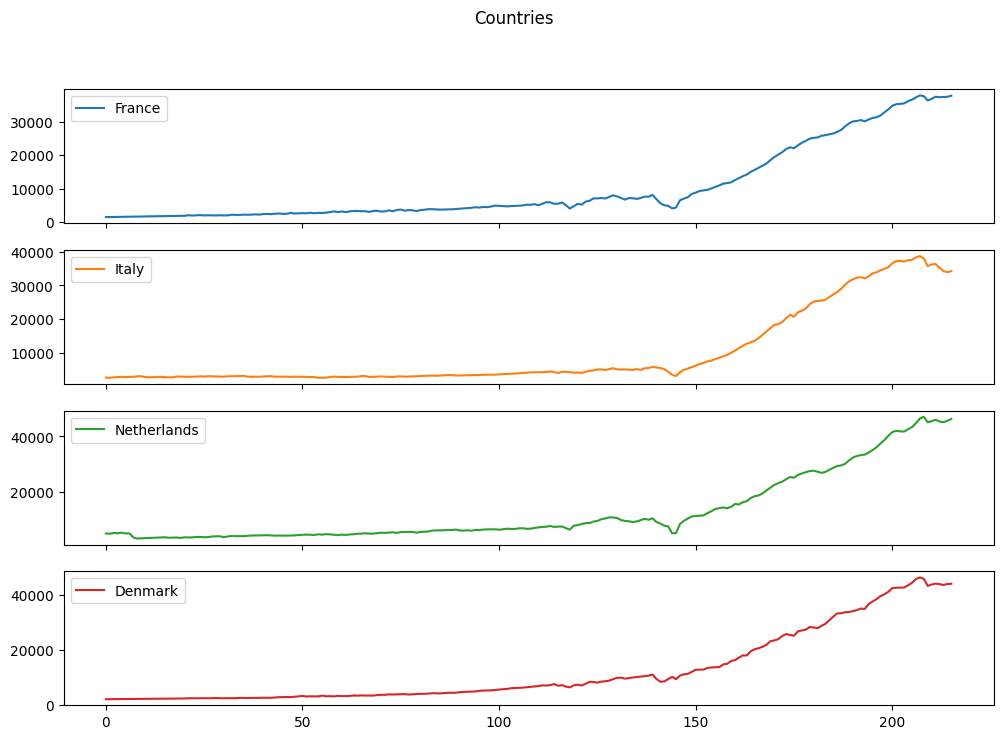

In [ ]:
df = dataset[['France', 'Italy', 'Netherlands', 'Denmark']]

df.plot(subplots=True, figsize=(12, 8))
plt.suptitle("Countries")
plt.show()


In [ ]:
def adf_test(series, title):
    print(f'ADF test for {title}:')
    for reg in ['c', 'ct']:
        result = adfuller(series, regression=reg, autolag='AIC')
        print(f'  {reg}: statistic = {result[0]:.4f}, p-value = {result[1]:.4f}')
    print()

def kpss_test(series, title):
    print(f'KPSS test for {title}:')
    for reg in ['c', 'ct']:
        stat, p_value, lags, crit = kpss(series, regression=reg, nlags='auto')
        print(f'  {reg}: statistic = {stat:.4f}, p-value = {p_value:.4f}')
    print()

for col in df.columns:
    adf_test(df[col], col)
    kpss_test(df[col], col)

ADF test for France:
  c: statistic = 2.2736, p-value = 0.9989
  ct: statistic = -0.2207, p-value = 0.9912

KPSS test for France:
  c: statistic = 1.7191, p-value = 0.0100
  ct: statistic = 0.4990, p-value = 0.0100

ADF test for Italy:
  c: statistic = -2.8611, p-value = 0.0501
  ct: statistic = -3.4013, p-value = 0.0512

KPSS test for Italy:
  c: statistic = 1.5450, p-value = 0.0100
  ct: statistic = 0.4881, p-value = 0.0100

ADF test for Netherlands:
  c: statistic = 3.3617, p-value = 1.0000
  ct: statistic = 0.2716, p-value = 0.9961

KPSS test for Netherlands:
  c: statistic = 1.6828, p-value = 0.0100
  ct: statistic = 0.4919, p-value = 0.0100

ADF test for Denmark:
  c: statistic = 3.5489, p-value = 1.0000
  ct: statistic = -0.1141, p-value = 0.9929

KPSS test for Denmark:
  c: statistic = 1.7816, p-value = 0.0100
  ct: statistic = 0.5132, p-value = 0.0100



In [ ]:
from statsmodels.tsa.stattools import coint

print("Engle‑Granger tests for all three variables (Куры Москва, СПб, Свердловская область):")
# Different choices of dependent variable
for dep in df.columns:
    others = [c for c in df.columns if c != dep]
    # coint function requires y and x (can be multiple x)
    result = coint(df[dep], df[others], trend='ct')  # constant in cointegrating relation
    print(f" Dependent: {dep}, test statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")

Engle‑Granger tests for all three variables (Куры Москва, СПб, Свердловская область):
 Dependent: France, test statistic = -4.3596, p-value = 0.0600
 Dependent: Italy, test statistic = -4.1612, p-value = 0.0969
 Dependent: Netherlands, test statistic = -3.3214, p-value = 0.4250
 Dependent: Denmark, test statistic = -4.9364, p-value = 0.0111


In [ ]:
df = df[['France', 'Italy', 'Denmark']]

In [ ]:
from statsmodels.tsa.stattools import coint

pairs = [('France', 'Italy'),
         ('France', 'Denmark'),
         ('Italy', 'Denmark')]
print("Pairwise Engle‑Granger tests:")
for (y, x) in pairs:
    result = coint(df[y], df[x], trend='c')
    print(f" ({y}, {x}): statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")

Pairwise Engle‑Granger tests:
 (France, Italy): statistic = -1.3688, p-value = 0.8080
 (France, Denmark): statistic = -3.5774, p-value = 0.0261
 (Italy, Denmark): statistic = -1.6062, p-value = 0.7182


In [ ]:
data = df.values
lag_order = select_order(data, maxlags=4, deterministic='ci')
print(lag_order.summary())

 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       34.97       35.21   1.541e+15       35.07
1       34.67      35.05*   1.143e+15      34.83*
2       34.69       35.21   1.162e+15       34.90
3       34.60       35.26   1.060e+15       34.87
4      34.55*       35.36  1.016e+15*       34.88
-------------------------------------------------


In [ ]:
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen

jres = coint_johansen(data, det_order=2, k_ar_diff=1)

print("Trace statistic:")
print(jres.lr1)
print("Critical values (90%, 95%, 99%):")
print(jres.cvt)
print("\nMax eigenvalue statistic:")
print(jres.lr2)
print("Critical values:")
print(jres.cvm)

Trace statistic:
[61.47338237 15.20903504  2.48222938]
Critical values (90%, 95%, 99%):
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]

Max eigenvalue statistic:
[46.26434734 12.72680565  2.48222938]
Critical values:
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]


In [ ]:
vecm_model = VECM(data, k_ar_diff=1, coint_rank=1, deterministic='cilt')
vecm_res = vecm_model.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation y1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1          0.2753      0.091      3.031      0.002       0.097       0.453
L1.y2          0.1101      0.087      1.260      0.208      -0.061       0.281
L1.y3         -0.0562      0.074     -0.759      0.448      -0.201       0.089
Det. terms outside the coint. relation & lagged endog. parameters for equation y2
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1          0.1914      0.089      2.154      0.031       0.017       0.366
L1.y2          0.3874      0.086      4.529      0.000       0.220       0.555
L1.y3         -0.0271      0.072     -0.373      0.709      -0.169       0.115
Det. terms outside the coint. relation & lagge

In [ ]:
resid = vecm_res.resid

# Ljung‑Box test for autocorrelation (lag 10)
from statsmodels.stats.diagnostic import acorr_ljungbox
for i, col in enumerate(['France', 'Italy', 'Denmark']):
    lb_result = acorr_ljungbox(resid[:, i], lags=[10], return_df=True)
    # In some versions, the column is 'lb_pvalue', in others 'pvalue'
    if 'lb_pvalue' in lb_result.columns:
        pval = lb_result['lb_pvalue'].iloc[0]
    else:
        pval = lb_result['pvalue'].iloc[0]
    print(f'{col}: Ljung‑Box p-value (lag 10) = {pval:.4f}')

# ARCH test
from statsmodels.stats.diagnostic import het_arch
for i, col in enumerate(['France', 'Italy', 'Denmark']):
    arch_stat, p_value, _, _ = het_arch(resid[:, i])
    print(f'{col}: ARCH test p-value = {p_value:.4f}')

# Multivariate normality
import pingouin as pg
norm_test = pg.multivariate_normality(resid)
print(norm_test)

France: Ljung‑Box p-value (lag 10) = 0.0740
Italy: Ljung‑Box p-value (lag 10) = 0.0001
Denmark: Ljung‑Box p-value (lag 10) = 0.4465
France: ARCH test p-value = 0.0006
Italy: ARCH test p-value = 0.0000
Denmark: ARCH test p-value = 0.4504
HZResults(hz=np.float64(13.939815718807333), pval=np.float64(2.995333358814237e-58), normal=False)


Det. terms outside the coint. relation & lagged endog. parameters for equation y1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1          0.4363      0.203      2.147      0.032       0.038       0.835
L1.y2         -0.1573      0.149     -1.055      0.291      -0.450       0.135
L1.y3          0.0640      0.096      0.667      0.505      -0.124       0.252
L2.y1         -0.0274      0.186     -0.147      0.883      -0.392       0.337
L2.y2         -0.0742      0.136     -0.545      0.586      -0.341       0.193
L2.y3          0.0524      0.098      0.534      0.593      -0.140       0.244
L3.y1         -0.1123      0.192     -0.585      0.558      -0.488       0.264
L3.y2          0.1114      0.138      0.806      0.420      -0.159       0.382
L3.y3          0.2047      0.096      2.131      0.033       0.016       0.393
L4.y1          0.0153      0.168      0.091      

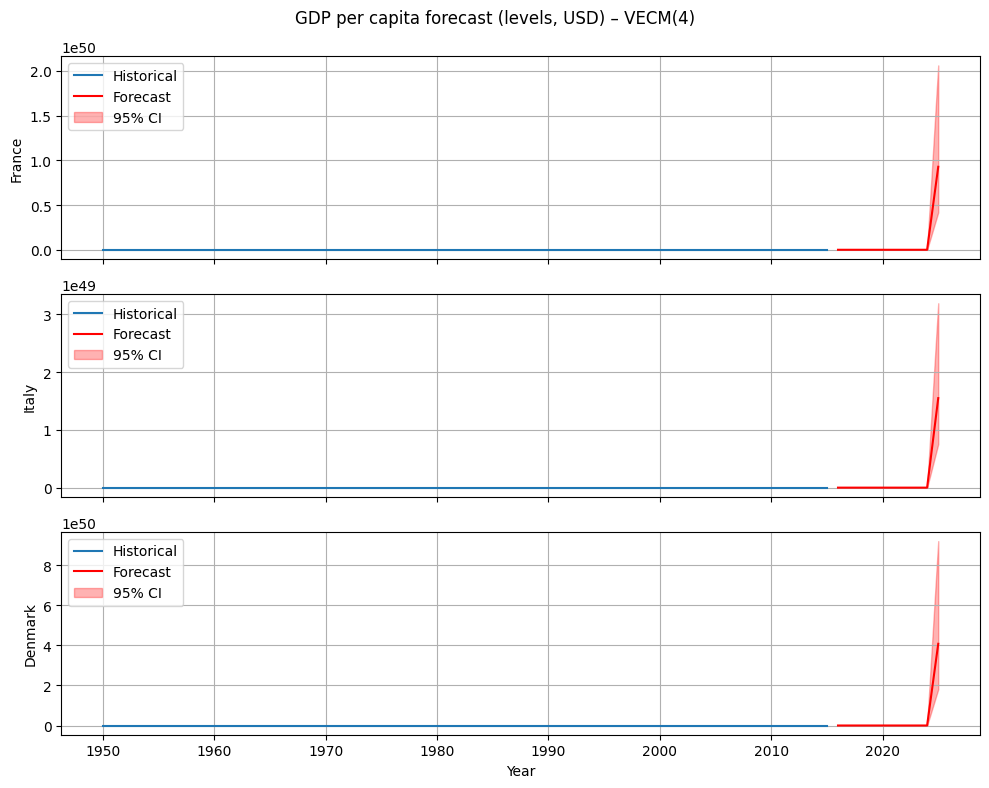


'to_var' not available; manual IRF/FEVD could be implemented.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import pingouin as pg

# Load GDP data (already logged, 1950–2025)
file_gdp = 'GDP per capita from 1800 (1).xlsx'
gdp_df = pd.read_excel(file_gdp, sheet_name='Лист1', index_col=0)
countries = ['France', 'Italy', 'Denmark']
gdp_log = np.log(gdp_df[countries]).loc[1950:].dropna()
data = gdp_log.values

# Estimate VECM with k_ar_diff=4, r=1, trend inside cointegration
vecm_model = VECM(data, k_ar_diff=4, coint_rank=1, deterministic='cilt')
vecm_res = vecm_model.fit()
print(vecm_res.summary())

# Residual diagnostics
resid = vecm_res.resid

print("\n--- Residual Diagnostics ---")
for i, col in enumerate(gdp_log.columns):
    lb = acorr_ljungbox(resid[:, i], lags=[10], return_df=True)
    pval = lb['lb_pvalue'].iloc[0] if 'lb_pvalue' in lb.columns else lb['pvalue'].iloc[0]
    print(f"{col}: Ljung‑Box p-value (lag 10) = {pval:.4f}")

for i, col in enumerate(gdp_log.columns):
    arch_stat, p_value, _, _ = het_arch(resid[:, i])
    print(f"{col}: ARCH test p-value = {p_value:.4f}")

norm_test = pg.multivariate_normality(resid)
print(norm_test)

# Forecasting (10 years ahead)
steps = 10
fc = vecm_res.predict(steps=steps, alpha=0.05)
if isinstance(fc, tuple):
    f, lower, upper = fc
else:
    f = fc; lower = upper = None

# Reconstruct levels (log) and exponentiate
last_levels = data[-1, :]
forecast_levels = np.zeros((steps, 3))
for t in range(steps):
    if t == 0:
        forecast_levels[t, :] = last_levels + f[t, :]
    else:
        forecast_levels[t, :] = forecast_levels[t-1, :] + f[t, :]

if lower is not None:
    lower_levels = np.zeros((steps, 3))
    upper_levels = np.zeros((steps, 3))
    for t in range(steps):
        if t == 0:
            lower_levels[t, :] = last_levels + lower[t, :]
            upper_levels[t, :] = last_levels + upper[t, :]
        else:
            lower_levels[t, :] = lower_levels[t-1, :] + lower[t, :]
            upper_levels[t, :] = upper_levels[t-1, :] + upper[t, :]

forecast_levels_exp = np.exp(forecast_levels)
if lower is not None:
    lower_levels_exp = np.exp(lower_levels)
    upper_levels_exp = np.exp(upper_levels)

last_year = gdp_log.index[-1]
forecast_years = np.arange(last_year + 1, last_year + steps + 1)
forecast_df = pd.DataFrame(forecast_levels_exp, columns=gdp_log.columns, index=forecast_years)
if lower is not None:
    lower_df = pd.DataFrame(lower_levels_exp, columns=gdp_log.columns, index=forecast_years)
    upper_df = pd.DataFrame(upper_levels_exp, columns=gdp_log.columns, index=forecast_years)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, col in enumerate(gdp_log.columns):
    axes[i].plot(gdp_log.index, np.exp(gdp_log[col]), label='Historical')
    axes[i].plot(forecast_df.index, forecast_df[col], label='Forecast', color='red')
    if lower is not None:
        axes[i].fill_between(forecast_df.index, lower_df[col], upper_df[col],
                             alpha=0.3, color='red', label='95% CI')
    axes[i].set_ylabel(col)
    axes[i].legend()
    axes[i].grid(True)
axes[-1].set_xlabel('Year')
plt.suptitle('GDP per capita forecast (levels, USD) – VECM(4)')
plt.tight_layout()
plt.show()

# IRF/FEVD (if to_var available)
try:
    var_rep = vecm_res.to_var()
    irf = var_rep.irf(periods=20)
    irf.plot(orth=True)
    plt.show()
    fevd = var_rep.fevd(periods=20)
    fevd.plot()
    plt.show()
except AttributeError:
    print("\n'to_var' not available; manual IRF/FEVD could be implemented.")

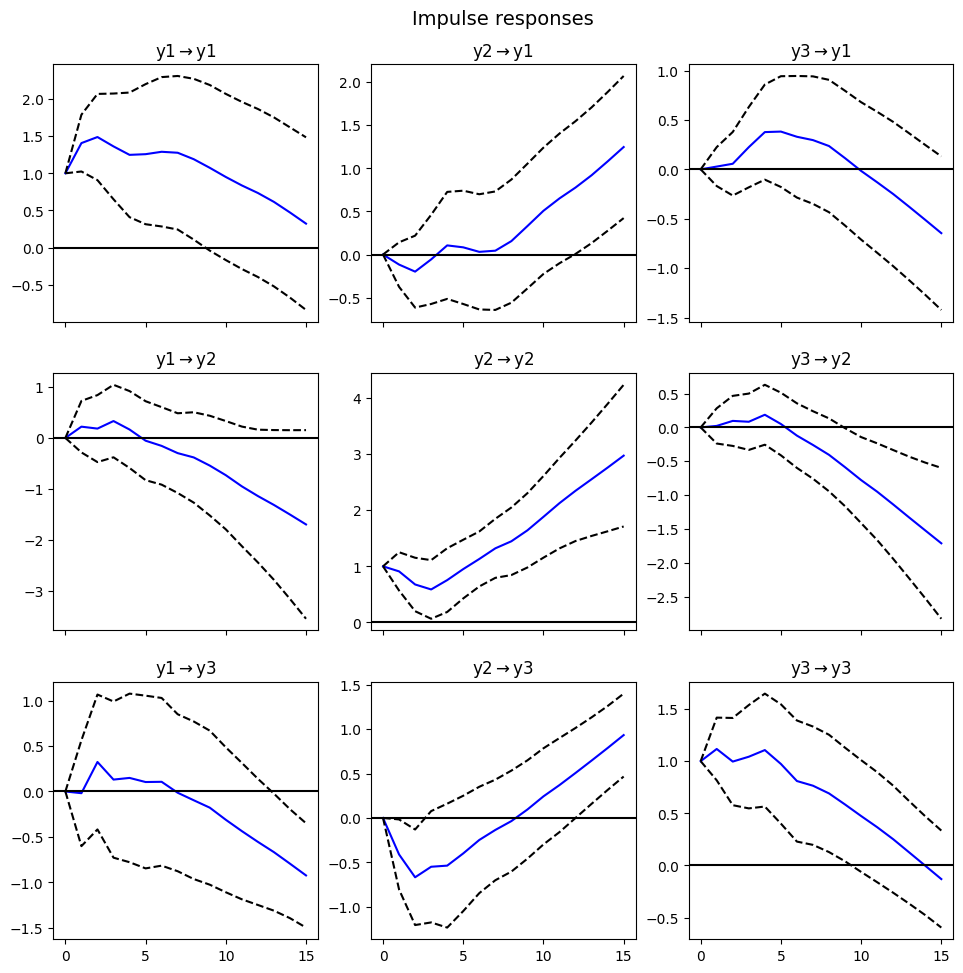

In [ ]:
from statsmodels.tsa.vector_ar import irf
irf = vecm_res.irf(15)
irf.plot(orth = False)
plt.show()

Task 3

In [ ]:
df = pd.read_excel('/content/Data1.xlsx')
df.head()

,"Фарш мясной, кг","Свинина (кроме бескостного мяса), кг","Сосиски, сардельки, кг"
0,49.84,43.41,48.33
1,49.85,43.31,48.42
2,50.01,43.24,48.58
3,50.08,43.31,48.68
4,50.65,44.07,49.23


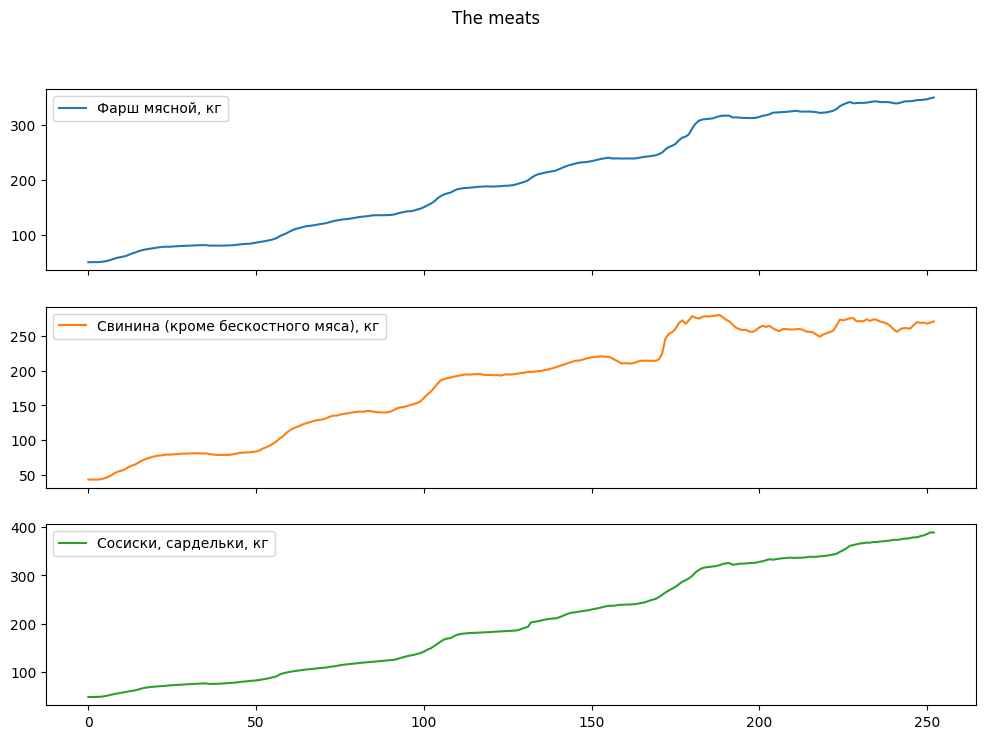

In [ ]:
df.plot(subplots=True, figsize=(12, 8))
plt.suptitle("The meats")
plt.show()

In [ ]:
def adf_test(series, title):
    print(f'ADF test for {title}:')
    for reg in ['c', 'ct']:
        result = adfuller(series, regression=reg, autolag='AIC')
        print(f'  {reg}: statistic = {result[0]:.4f}, p-value = {result[1]:.4f}')
    print()

def kpss_test(series, title):
    print(f'KPSS test for {title}:')
    for reg in ['c', 'ct']:
        stat, p_value, lags, crit = kpss(series, regression=reg, nlags='auto')
        print(f'  {reg}: statistic = {stat:.4f}, p-value = {p_value:.4f}')
    print()

for col in df.columns:
    adf_test(df[col], col)
    kpss_test(df[col], col)

ADF test for Фарш мясной, кг:
  c: statistic = -0.1175, p-value = 0.9477
  ct: statistic = -2.7409, p-value = 0.2195

KPSS test for Фарш мясной, кг:
  c: statistic = 2.3963, p-value = 0.0100
  ct: statistic = 0.2073, p-value = 0.0133

ADF test for Свинина (кроме бескостного мяса), кг:
  c: statistic = -1.3902, p-value = 0.5870
  ct: statistic = -2.3097, p-value = 0.4286

KPSS test for Свинина (кроме бескостного мяса), кг:
  c: statistic = 2.3285, p-value = 0.0100
  ct: statistic = 0.3521, p-value = 0.0100

ADF test for Сосиски, сардельки, кг:
  c: statistic = 0.1943, p-value = 0.9719
  ct: statistic = -2.4471, p-value = 0.3549

KPSS test for Сосиски, сардельки, кг:
  c: statistic = 2.3894, p-value = 0.0100
  ct: statistic = 0.3848, p-value = 0.0100



In [ ]:
from statsmodels.tsa.stattools import coint

print("Engle‑Granger tests for all three variables:")
# Different choices of dependent variable
for dep in df.columns:
    others = [c for c in df.columns if c != dep]
    # coint function requires y and x (can be multiple x)
    result = coint(df[dep], df[others], trend='ct')  # constant in cointegrating relation
    print(f" Dependent: {dep}, test statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")

Engle‑Granger tests for all three variables:
 Dependent: Фарш мясной, кг, test statistic = -2.9795, p-value = 0.4409
 Dependent: Свинина (кроме бескостного мяса), кг, test statistic = -4.0734, p-value = 0.0564
 Dependent: Сосиски, сардельки, кг, test statistic = -2.8904, p-value = 0.4894


In [ ]:
from statsmodels.tsa.stattools import coint

pairs = [('Фарш мясной, кг', 'Свинина (кроме бескостного мяса), кг'),
         ('Фарш мясной, кг', 'Сосиски, сардельки, кг'),
         ('Свинина (кроме бескостного мяса), кг', 'Сосиски, сардельки, кг')]
print("Pairwise Engle‑Granger tests:")
for (y, x) in pairs:
    result = coint(df[y], df[x], trend='c')
    print(f" ({y}, {x}): statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")

Pairwise Engle‑Granger tests:
 (Фарш мясной, кг, Свинина (кроме бескостного мяса), кг): statistic = -1.4612, p-value = 0.7758
 (Фарш мясной, кг, Сосиски, сардельки, кг): statistic = -0.8324, p-value = 0.9303
 (Свинина (кроме бескостного мяса), кг, Сосиски, сардельки, кг): statistic = -1.5415, p-value = 0.7449


In [ ]:
data = df.values
lag_order = select_order(data, maxlags=12, deterministic='ci')
print(lag_order.summary())

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        1.800       2.018       6.052       1.888
1       0.9419      1.290*       2.565      1.082*
2       0.9110       1.390       2.487       1.104
3       0.8887       1.498       2.433       1.134
4       0.8937       1.633       2.446       1.192
5       0.8983       1.768       2.458       1.249
6      0.8596*       1.860      2.366*       1.263
7       0.8832       2.014       2.425       1.339
8       0.8889       2.151       2.441       1.397
9       0.9425       2.335       2.579       1.503
10      0.9689       2.492       2.652       1.582
11      0.9116       2.565       2.508       1.578
12      0.8626       2.646       2.393       1.581
--------------------------------------------------


In [ ]:
# Using k_ar_diff = selected lag - 1
k_ar_diff = 2   # for example, if lag_order selects p=3
jres = coint_johansen(data, det_order=0, k_ar_diff=0)
print("Trace statistic:", jres.lr1)
print("Critical values (90%, 95%, 99%):")
print(jres.cvt)
print("\nMax eigenvalue statistic:", jres.lr2)
print("Critical values:")
print(jres.cvm)

Trace statistic: [115.91086476  35.32794762  11.86124107]
Critical values (90%, 95%, 99%):
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Max eigenvalue statistic: [80.58291714 23.46670655 11.86124107]
Critical values:
[[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [ ]:
vecm_model = VECM(data, k_ar_diff=2, coint_rank=1, deterministic='cilt')
vecm_res = vecm_model.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation y1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1          0.6397      0.082      7.774      0.000       0.478       0.801
L1.y2          0.1260      0.033      3.778      0.000       0.061       0.191
L1.y3          0.0624      0.076      0.821      0.412      -0.087       0.211
L2.y1         -0.0792      0.085     -0.936      0.349      -0.245       0.087
L2.y2         -0.0595      0.033     -1.785      0.074      -0.125       0.006
L2.y3          0.0501      0.076      0.657      0.511      -0.099       0.200
Det. terms outside the coint. relation & lagged endog. parameters for equation y2
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1         -0.1388      0.181     -0.767   

In [ ]:
resid = vecm_res.resid

# Ljung‑Box test for autocorrelation (lag 10)
from statsmodels.stats.diagnostic import acorr_ljungbox
for i, col in enumerate(['France', 'Italy', 'Denmark']):
    lb_result = acorr_ljungbox(resid[:, i], lags=[10], return_df=True)
    # In some versions, the column is 'lb_pvalue', in others 'pvalue'
    if 'lb_pvalue' in lb_result.columns:
        pval = lb_result['lb_pvalue'].iloc[0]
    else:
        pval = lb_result['pvalue'].iloc[0]
    print(f'{col}: Ljung‑Box p-value (lag 10) = {pval:.4f}')

# ARCH test
from statsmodels.stats.diagnostic import het_arch
for i, col in enumerate(['France', 'Italy', 'Denmark']):
    arch_stat, p_value, _, _ = het_arch(resid[:, i])
    print(f'{col}: ARCH test p-value = {p_value:.4f}')

# Multivariate normality
import pingouin as pg
norm_test = pg.multivariate_normality(resid)
print(norm_test)

France: Ljung‑Box p-value (lag 10) = 0.0532
Italy: Ljung‑Box p-value (lag 10) = 0.0000
Denmark: Ljung‑Box p-value (lag 10) = 0.8103
France: ARCH test p-value = 0.0222
Italy: ARCH test p-value = 0.0006
Denmark: ARCH test p-value = 0.5837
HZResults(hz=np.float64(16.89480016538672), pval=np.float64(3.1976049939435104e-68), normal=False)


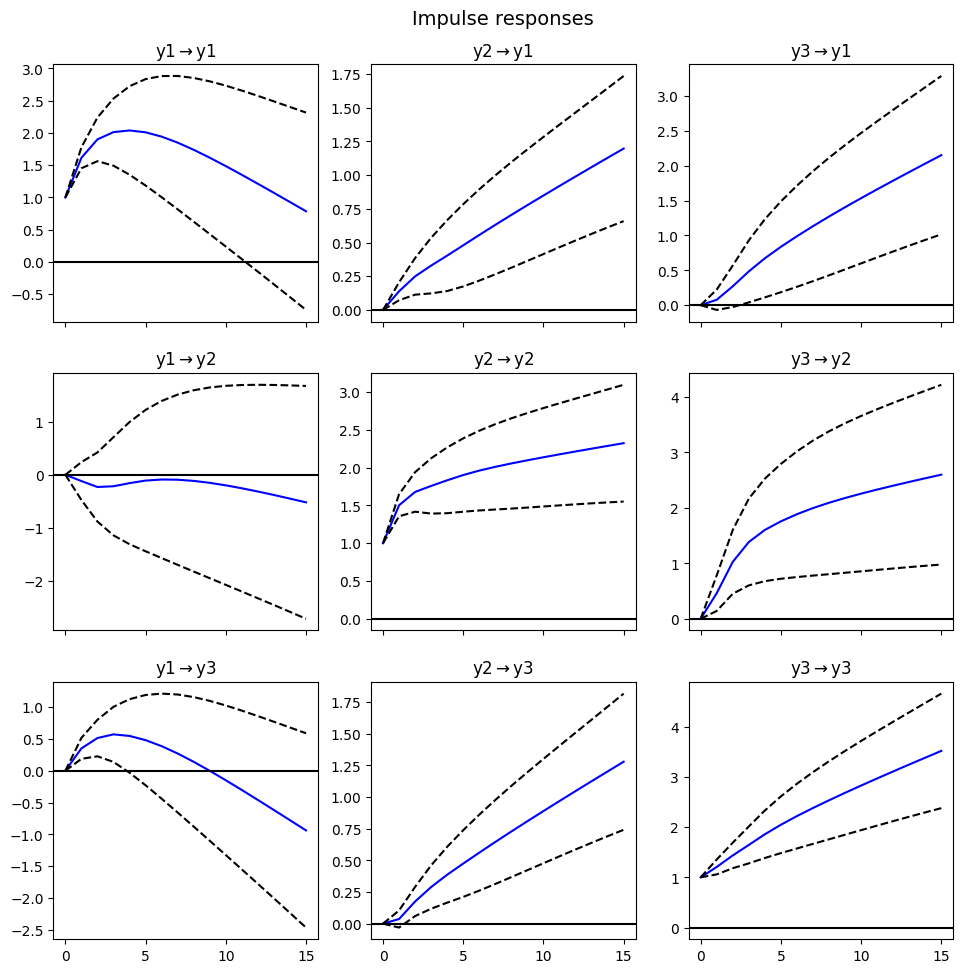

In [ ]:
from statsmodels.tsa.vector_ar import irf
irf = vecm_res.irf(15)
irf.plot(orth = False)
plt.show()